In [1]:
# ============================================================
# Longform 영상 성공 예측 ML (Gemini 임베딩 추가 버전)
# ------------------------------------------------------------
# [태스크]
#   - 이진 분류. 영상이 '성공(grade=1)' 일지 '실패(grade=0)' 일지 예측.
#
# [학습 데이터셋]
#   - long_form_all.csv (1093 행, 이미 전처리/파생컬럼 끝난 상태)
#   - ALL 한 개 데이터셋만 사용 (IT/FnB 분리하지 않고 합쳐서 학습).
#     도메인 분포 차이는 'domain' 자체를 입력 피쳐로 흘려서 모델이 학습.
#
# [입력 피쳐]
#   1) 구조형 16개 (structured_feature_cols):
#        domain, description_missing_flag, tags_missing_flag, tags_count,
#        영상길이(초), caption, category_name, length_bucket,
#        cls_content_type, cls_marketing_purpose, cls_cta_type,
#        cls_is_series, cls_is_collaboration,
#        definition, embeddable, has_paid_product_placement
#      카테고리는 OneHotEncoder(handle_unknown='ignore'),
#      수치는 median impute (+ MLP 한정 StandardScaler).
#   2) 텍스트 임베딩 768개 (emb_0 .. emb_767):
#        title + description 을 Gemini gemini-embedding-2 로 768차원 임베딩.
#        ColumnTransformer 에서 raw passthrough (자동 L2 정규화돼 있음).
#   -> 합계 16 + 768 = 784 차원 입력.
#
# [제외한 피쳐]
#   - 시간 계열: upload_year/month/dayofweek/hour/quarter, is_weekend, upload_time_bucket
#     (업로드 시점 잡음 회피 목적)
#   - 문자열 길이: description_length
#     (의미는 임베딩이 더 잘 잡아주므로 중복)
#
# [타겟]
#   - grade  ∈ {0, 1}  (실패 0 / 성공 1)
#
# [학습/평가 분할]
#   - train_test_split(test_size=0.2, stratify=y, random_state=42)
#   - CV 는 X_train 안에서만 5-fold StratifiedKFold (holdout 누수 방지).
#
# [평가 metric]
#   - CV   : roc_auc, average_precision (PR-AUC)  -> cv_roc_auc_mean, cv_pr_auc_mean
#   - Test : accuracy, precision, recall, f1, roc_auc, pr_auc (== average_precision)
#
# [모델 비교 / best 선정 metric]
#   - 모델 비교는 test_pr_auc 기준 (성공 클래스 탐지 성능 관점).
#   - best_models.json 도 test_pr_auc 내림차순 1등 모델을 데이터셋별로 기록.
#
# [학습 모델 4종]
#   - RandomForest (n_estimators=300, class_weight='balanced')
#   - XGBoost      (n_estimators=300, depth=4, lr=0.05)
#   - CatBoost     (iterations=500, depth=5, lr=0.05)
#   - MLPClassifier (256-64, adam, early_stopping)  <- 유일하게 scale_numeric=True
#   모두 동일한 sklearn Pipeline (preprocess + estimator) 으로 처리.
#
# [임베딩 캐싱 / 중간 저장]
#   - 캐시 파일: embeddings/gemini_emb_dim768.parquet
#   - PK: video_id
#   - SAVE_EVERY_N_BATCHES (기본 5) 마다 디스크에 atomic write 부분 저장.
#     중단 후 재실행 시 캐시에 있는 video_id 는 skip 하고 남은 것만 호출.
#
# [출력 / 저장]
#   - models/ALL__{RandomForest,XGBoost,CatBoost,MLP}.joblib  (sklearn Pipeline 통째로)
#   - models/best_models.json   {"ALL": "<모델명>"}
#   - models/meta.json          {gemini_model, embedding_dim, structured_feature_cols,
#                                embedding_feature_cols, all_feature_cols, target}
#
# [해석]
#   - Feature Importance (트리 3종): 임베딩 768개를 'embedding(sum)' 으로 묶어 표시.
#   - SHAP (ALL 데이터셋, best 트리 모델 자동 선정. MLP 가 1등이면 차순위 트리 fallback):
#       * grouped bar plot  (embedding 합산)
#       * structured-only dot summary
#       * waterfall (best 가 CatBoost 일 때만, 단일 샘플)
#
# [추론과의 일관성]
#   - 추론은 predict_longform.py 에서. 모델/메타는 위 models/ 디렉토리에서 로드.
#   - 추론은 본 스크립트의 로직(prepare_text 의 prefix/sentinel/format,
#     length_bucket 임계값, structured_feature_cols 키, all_feature_cols 컬럼 순서)
#     과 정확히 동일하게 1행을 만들어 전처리 -> 임베딩 -> 모델 예측.
# ============================================================

import os
import time
import warnings
import platform
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from dotenv import load_dotenv

warnings.filterwarnings('ignore')

# 한글 폰트 설정 (그래프에 한글 제목/레이블이 깨지지 않게)
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False
pd.set_option('display.max_colwidth', None)

# 프로젝트 루트 경로를 한 번만 잡아서 .env / 데이터 / 캐시 / 모델 모두에 재사용.
# Jupyter (.ipynb) 에는 __file__ 이 정의되어 있지 않아 NameError 가 나므로
# 그 경우엔 현재 작업 디렉토리(cwd) 로 fallback.
try:
    PROJECT_ROOT = Path(__file__).resolve().parent
except NameError:
    PROJECT_ROOT = Path.cwd()

# .env 에서 GEMINI_API_KEY, GEMINI_EMBEDDING_MODEL 을 읽는다.
load_dotenv(dotenv_path=PROJECT_ROOT / '.env')

GEMINI_API_KEY = os.environ.get('GEMINI_API_KEY')
GEMINI_EMBEDDING_MODEL = os.environ.get('GEMINI_EMBEDDING_MODEL', 'gemini-embedding-2')

# 임베딩 차원과 캐시 경로는 한 곳에서만 관리. 차원을 바꿀 일이 생기면
# 파일명에 dim 이 들어가 있어서 이전 캐시와 충돌하지 않는다.
EMBEDDING_DIM = 768
EMBEDDING_CACHE_PATH = PROJECT_ROOT / 'embeddings' / f'gemini_emb_dim{EMBEDDING_DIM}.parquet'

assert GEMINI_API_KEY, 'GEMINI_API_KEY가 .env에 없습니다.'
print(f'[ENV] model={GEMINI_EMBEDDING_MODEL}, dim={EMBEDDING_DIM}')
print(f'[ENV] cache={EMBEDDING_CACHE_PATH}')

[ENV] model=gemini-embedding-2, dim=768
[ENV] cache=c:\Users\610ha\Desktop\study\final_project\works\Haeun\Dashboard\longform\embeddings\gemini_emb_dim768.parquet


In [2]:
# ============================================================
# 데이터 로드
# - long_form_all.csv 는 이미 전처리/파생컬럼이 끝난 상태라 여기서는
#   추가 가공 없이 그대로 읽기만 한다.
# - utf-8-sig: CSV 첫 글자에 BOM 이 있어서 utf-8 로 읽으면
#   첫 컬럼명에 깨진 문자가 들어가는 문제가 있어 sig 변종을 사용.
# ============================================================

CSV_PATH = PROJECT_ROOT / 'long_form_all.csv'
df_raw = pd.read_csv(CSV_PATH, encoding='utf-8-sig')

print(f'[DATA] shape={df_raw.shape}')
print(f'[DATA] columns(first 10)={list(df_raw.columns)[:10]}')
print(f'[DATA] grade dist=\n{df_raw["grade"].value_counts(normalize=True)}')

[DATA] shape=(1093, 46)
[DATA] columns(first 10)=['domain', 'grade', 'score1', 'score2', 'video_id', 'title', 'description', 'description_length', 'description_missing_flag', '업로드일시']
[DATA] grade dist=
grade
0    0.52516
1    0.47484
Name: proportion, dtype: float64


In [3]:
# ============================================================
# Gemini 임베딩 입력 텍스트 빌더
# - gemini-embedding-2 는 task_type 파라미터를 지원하지 않는 모델이라
#   "어떤 작업을 위한 임베딩인지"를 prompt prefix 로 직접 표기한다.
#   (공식 문서가 권장하는 방식)
# - title 과 description 을 한 문자열로 합치되, description 이 비어 있으면
#   sentinel "(설명 없음)" 으로 채워서 빈 문자열을 모델에 보내는 사고를 방지.
#   description 의 결측 자체는 description_missing_flag 라는 별도 구조형
#   피쳐로 이미 보존되어 있으므로 sentinel 로 덮어써도 정보 손실은 없다.
# ============================================================

EMPTY_TEXT_SENTINEL = "(설명 없음)"
TEXT_PREFIX = "task: classification | query: "


def prepare_text(title, desc) -> str:
    """Gemini 임베딩에 보낼 한 건 입력 문자열을 만든다.

    형식: "{TEXT_PREFIX}TITLE: {title}\\nDESCRIPTION: {desc}".
    title/desc 가 None/NaN/공백이면 빈 문자열로 처리하고, desc 가 비면 sentinel
    "(설명 없음)" 으로 대체해서 빈 입력 거절을 막는다.
    """
    title = (str(title) if title is not None and pd.notna(title) else "").strip()
    desc = (str(desc) if desc is not None and pd.notna(desc) else "").strip()
    if not desc:
        desc = EMPTY_TEXT_SENTINEL
    return f"{TEXT_PREFIX}TITLE: {title}\nDESCRIPTION: {desc}"

In [4]:
# ============================================================
# Gemini 임베딩 호출 (배치 + 재시도)
# - google-genai 공식 SDK 사용
# - output_dimensionality=768 로 지정하면 SDK 가 알아서 L2 정규화까지 해준다
#   (3072 미만 차원에서만 자동 정규화. 우리는 768 이라 안전.)
# - 100건씩 묶어서 호출. 일부 배치 실패는 지수 backoff 로 최대 3회 재시도.
# ============================================================

from google import genai
from google.genai import types

_genai_client = genai.Client(api_key=GEMINI_API_KEY)

import re

# gemini-embedding-2 는 embed_content 에 contents=list 를 줘도 한 번에 1건만 임베딩해
# 돌려주는 동작이라 (실측: req=25 -> resp=1) 텍스트당 한 번씩 호출해야 한다.
# 그래서 BATCH_SIZE 는 "API 가 받는 묶음" 이 아니라 "checkpoint / 진행률 단위" 의미.
# PER_CALL_INTERVAL 로 호출 간격을 조절 (free tier 100 RPM 안전 마진 0.7초 기본).
# Paid tier (3000 RPM 등) 라면 .env 에서 0.05 정도로 낮춰 가속.
BATCH_SIZE = int(os.environ.get('EMBEDDING_BATCH_SIZE', '25'))
PER_CALL_INTERVAL = float(os.environ.get('EMBEDDING_PER_CALL_INTERVAL', '0.7'))  # 초
MAX_RETRY = 5
RETRY_BASE_SLEEP = 2.0  # 초. 일시적 에러용 fallback. 429 는 응답의 retryDelay 를 우선.

# 429 에러 메시지 안 'retryDelay': '59s' 같은 권장 대기시간을 뽑아 쓰기 위한 정규식.
_RETRY_DELAY_RE = re.compile(r"retryDelay'?:\s*'?(\d+(?:\.\d+)?)s")


def _parse_retry_delay_seconds(err: Exception) -> float | None:
    """429 응답에서 Google 이 안내한 retryDelay 초를 뽑아낸다.

    SDK 가 던지는 예외 텍스트 안에 'retryDelay': '59s' 형태가 박혀 오는데,
    그 값을 따라야 다음 시도가 또 429 로 튕기지 않는다.
    파싱 실패 시 None.
    """
    m = _RETRY_DELAY_RE.search(str(err))
    if not m:
        return None
    try:
        return float(m.group(1))
    except (TypeError, ValueError):
        return None


def _embed_one(text: str) -> list[float]:
    """텍스트 1건 임베딩. 429 / 일시 에러 재시도 포함.

    gemini-embedding-2 는 호출당 1건만 처리해서, 진짜 batching 이 불가능하다.
    부분 결과 누락을 막기 위해 MAX_RETRY 안에 못 풀면 RuntimeError 로 명확히 실패.
    """
    last_err = None
    for attempt in range(MAX_RETRY):
        try:
            resp = _genai_client.models.embed_content(
                model=GEMINI_EMBEDDING_MODEL,
                contents=text,
                config=types.EmbedContentConfig(output_dimensionality=EMBEDDING_DIM),
            )
            return list(resp.embeddings[0].values)
        except Exception as e:
            last_err = e
            err_str = str(e)
            if '429' in err_str or 'RESOURCE_EXHAUSTED' in err_str:
                # API 가 알려준 retryDelay 가 있으면 그만큼 + 약간 여유. 없으면 60초.
                hinted = _parse_retry_delay_seconds(e)
                sleep_s = (hinted + 2.0) if hinted is not None else 60.0
                print(f'[WARN] rate limit (attempt {attempt+1}/{MAX_RETRY}). sleep {sleep_s:.1f}s (hinted={hinted}s)')
            else:
                sleep_s = RETRY_BASE_SLEEP * (2 ** attempt)
                print(f'[WARN] embed failed (attempt {attempt+1}/{MAX_RETRY}): {e}. sleep {sleep_s:.1f}s')
            time.sleep(sleep_s)
    raise RuntimeError(f'임베딩 생성 실패 ({MAX_RETRY}회 재시도): {last_err}')


def _embed_batch(texts: list[str]) -> list[list[float]]:
    """텍스트 묶음을 받아서 한 건씩 _embed_one 으로 호출.
    호출 사이에 PER_CALL_INTERVAL 만큼 sleep 으로 RPM 한도를 미리 안 넘게 한다.
    """
    out: list[list[float]] = []
    for i, text in enumerate(texts):
        if i > 0:
            time.sleep(PER_CALL_INTERVAL)
        out.append(_embed_one(text))
    return out


# 임베딩 중간 저장 주기. 5 배치(=BATCH_SIZE*5 건)마다 디스크에 부분 저장.
# 중단되어도 다음 실행에서 이어서 가능하게 하려는 안전장치.
SAVE_EVERY_N_BATCHES = int(os.environ.get('EMBEDDING_SAVE_EVERY_N_BATCHES', '5'))


def _save_cache_atomic(cache_path: Path, merged_df: pd.DataFrame) -> None:
    """parquet 을 atomic 하게 저장 (.tmp 로 쓴 뒤 rename)."""
    tmp_path = cache_path.with_suffix('.parquet.tmp')
    merged_df.to_parquet(tmp_path, index=False)
    tmp_path.replace(cache_path)

In [5]:
# ============================================================
# 입력 데이터프레임의 모든 영상에 대해 임베딩을 만들어 돌려주는 메인 함수.
#
# 동작 순서:
#   1) 입력 df 의 (video_id, title, description) 을 본다.
#   2) 디스크에 저장된 임베딩 캐시(parquet)가 있으면 먼저 로드한다.
#   3) 캐시에 아직 없는 video_id 만 추려 Gemini API 로 임베딩 생성.
#   4) 새로 만든 것을 캐시에 합쳐 저장하고, 입력 df 순서대로 반환.
# ============================================================

def load_or_create_embeddings(df: pd.DataFrame) -> pd.DataFrame:
    """입력 df 의 (video_id, title, description) 기준으로 임베딩을 채워서 반환.

    반환 컬럼: ['video_id', 'embedding']
        embedding 은 list[float] (length = EMBEDDING_DIM).
    반환 순서는 입력 df 순서를 유지한다 (downstream merge 가 편하도록).
    """
    EMBEDDING_CACHE_PATH.parent.mkdir(parents=True, exist_ok=True)

    if EMBEDDING_CACHE_PATH.exists():
        cache_df = pd.read_parquet(EMBEDDING_CACHE_PATH)
        print(f'[CACHE] loaded {len(cache_df)} embeddings from {EMBEDDING_CACHE_PATH.name}')
    else:
        # 캐시가 없을 때는 동일 스키마의 빈 DataFrame 으로 시작.
        # 빈 DataFrame 의 dtype 을 명시해 두면 이후 isin/merge 에서 타입 경고가 안 난다.
        cache_df = pd.DataFrame({
            'video_id': pd.Series(dtype=str),
            'embedding': pd.Series(dtype=object),
        })
        print('[CACHE] no existing cache')

    cached_ids = set(cache_df['video_id'].tolist())
    needed = df[~df['video_id'].isin(cached_ids)][['video_id', 'title', 'description']].copy()
    # 같은 영상이 여러 번 들어와도 한 번만 호출. (현재 데이터에는 중복이 없을 가능성이 높지만 방어용.)
    needed = needed.drop_duplicates(subset='video_id').reset_index(drop=True)

    print(f'[CACHE] need new embeddings: {len(needed)} / {len(df)} rows')

    if len(needed) > 0:
        # 배치 호출 + 분당 페이스 조절 + N 배치마다 디스크 부분저장.
        # 부분저장 덕에 중간에 죽어도 다음 실행에서 캐시가 hit 되어 이어서 진행된다.
        pending_ids: list[str] = []
        pending_vecs: list[list[float]] = []
        batch_starts = list(range(0, len(needed), BATCH_SIZE))

        def _flush_to_cache(local_cache: pd.DataFrame) -> pd.DataFrame:
            """현재까지 쌓인 pending 을 cache 에 합쳐 저장하고 새 cache 반환."""
            if not pending_ids:
                return local_cache
            new_df = pd.DataFrame({
                'video_id': pending_ids,
                'embedding': [list(v) for v in pending_vecs],
            })
            merged = pd.concat([local_cache, new_df], ignore_index=True)
            # 중복 시 새 값 우선 (keep='last') -> 모델/차원 변경 후 재임베딩도 자연 갱신.
            merged = merged.drop_duplicates(subset='video_id', keep='last').reset_index(drop=True)
            _save_cache_atomic(EMBEDDING_CACHE_PATH, merged)
            print(f'[CACHE] checkpoint saved (+{len(pending_ids)} -> total {len(merged)})')
            pending_ids.clear()
            pending_vecs.clear()
            return merged

        for bi, i in enumerate(tqdm(batch_starts, desc='embedding')):
            chunk = needed.iloc[i:i + BATCH_SIZE]
            texts = [prepare_text(t, d) for t, d in zip(chunk['title'], chunk['description'])]
            # _embed_batch 내부에서 텍스트 1건씩 호출 + PER_CALL_INTERVAL sleep.
            vectors = _embed_batch(texts)
            if len(vectors) != len(chunk):
                raise RuntimeError(f'배치 응답 길이 불일치: req={len(chunk)} resp={len(vectors)}')
            pending_ids.extend(chunk['video_id'].tolist())
            pending_vecs.extend(vectors)

            # SAVE_EVERY_N_BATCHES 마다 또는 마지막 배치 직후 flush.
            if (bi + 1) % SAVE_EVERY_N_BATCHES == 0 or (bi + 1) == len(batch_starts):
                cache_df = _flush_to_cache(cache_df)

    # 입력 df 순서 그대로 반환. how='left' 라 순서가 보존된다.
    result = df[['video_id']].merge(cache_df, on='video_id', how='left')
    missing = result['embedding'].isna().sum()
    if missing > 0:
        raise RuntimeError(f'임베딩 누락 video_id가 {missing}건 있습니다.')
    return result

In [6]:
# 임베딩 생성 (캐시가 있으면 그대로 로드, 없으면 신규 생성).
emb_df = load_or_create_embeddings(df_raw)
print(f'[EMB] result rows={len(emb_df)}, sample dim={len(emb_df["embedding"].iloc[0])}')
assert len(emb_df["embedding"].iloc[0]) == EMBEDDING_DIM

[CACHE] loaded 1093 embeddings from gemini_emb_dim768.parquet
[CACHE] need new embeddings: 0 / 1093 rows
[EMB] result rows=1093, sample dim=768


In [7]:
# ============================================================
# 임베딩 list 를 emb_0 .. emb_767 컬럼으로 펼친 뒤 원본 df 와 결합.
# - 펼치는 이유: sklearn ColumnTransformer/CatBoost 모두 고정폭 컬럼이 필요.
# - float32 로 저장해서 dim=768 기준 한 행당 약 3KB 정도. 데이터셋 크기에 비례.
# ============================================================

def expand_embeddings(emb_df: pd.DataFrame) -> pd.DataFrame:
    """video_id + emb_0..emb_{D-1} 컬럼을 가진 wide 형태 DataFrame 으로 변환."""
    arr = np.vstack(emb_df['embedding'].to_list()).astype(np.float32)
    cols = [f'emb_{i}' for i in range(arr.shape[1])]
    out = pd.DataFrame(arr, columns=cols)
    out.insert(0, 'video_id', emb_df['video_id'].values)
    return out


emb_wide = expand_embeddings(emb_df)
df_full = df_raw.merge(emb_wide, on='video_id', how='left')

# 결합 후 임베딩 컬럼에 NaN 이 끼어 있으면 학습 단계에서 조용히 망가지므로
# 여기서 한 번 분명하게 검증한다.
assert df_full[[f'emb_{i}' for i in range(EMBEDDING_DIM)]].isna().sum().sum() == 0, '임베딩 결합 누락'
print(f'[MERGE] df_full shape={df_full.shape}')

[MERGE] df_full shape=(1093, 814)


In [8]:
# ============================================================
# Feature 컬럼 정의
# - 시간 관련 피쳐 제거: upload_year/month/dayofweek/hour/quarter,
#                       is_weekend, upload_time_bucket
#   (원본 데이터에는 있지만 모델 입력에서 의도적으로 제외)
# - 문자열 길이 피쳐 제거: description_length
#   (임베딩이 길이 정보를 더 풍부하게 담고 있어 중복 제거)
# - title/description 원문은 leakage 가 아닌 의미 피쳐로 간주.
#   타깃(grade)은 영상의 사후 성과로 정해지는 값이라
#   업로드 시점에 결정되는 텍스트와 데이터적으로 분리되어 있음.
# ============================================================

TARGET = 'grade'

structured_feature_cols = [
    # IT/FnB 를 분리해서 학습하지 않고 ALL 로만 학습하기 때문에,
    # domain 자체를 one-hot 피쳐로 모델에 흘려준다 (OneHotEncoder 가 자동 처리).
    'domain',
    'description_missing_flag',
    'tags_missing_flag', 'tags_count',
    '영상길이(초)',
    'caption',
    'category_name',
    'length_bucket',
    'cls_content_type', 'cls_marketing_purpose', 'cls_cta_type',
    'cls_is_series', 'cls_is_collaboration',
    'definition',
    'embeddable',
    'has_paid_product_placement',
]

embedding_feature_cols = [f'emb_{i}' for i in range(EMBEDDING_DIM)]

all_feature_cols = structured_feature_cols + embedding_feature_cols

# 컬럼 존재 검증. 데이터 변경이 있을 때 빨리 깨지도록.
missing = [c for c in all_feature_cols if c not in df_full.columns]
assert not missing, f'feature 누락: {missing}'
print(f'[FEAT] structured={len(structured_feature_cols)}, embedding={len(embedding_feature_cols)}, total={len(all_feature_cols)}')

[FEAT] structured=16, embedding=768, total=784


In [9]:
# ============================================================
# 학습 데이터셋: ALL 한 개만 사용한다.
# 도메인 분포 차이는 위에서 추가한 'domain' 피쳐(one-hot)가 흡수.
# datasets dict 형태는 학습 루프 호환을 위해 유지.
# ============================================================

datasets = {
    'ALL': df_full.reset_index(drop=True),
}

for name, d in datasets.items():
    print(f'[DS] {name}: shape={d.shape}, success_rate={d[TARGET].mean():.3f}')

[DS] ALL: shape=(1093, 814), success_rate=0.475


In [10]:
# ============================================================
# ML 라이브러리 + 공통 유틸
# - sklearn Pipeline + ColumnTransformer 로 4 모델 모두 같은 전처리 흐름을 공유.
#   CatBoost 도 sklearn 호환 인터페이스라 별도 분기 없이 같은 run_sklearn_model 로 처리.
# ============================================================

from sklearn.base import clone
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve,
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier


# ColumnTransformer 가 컬럼명 앞에 'emb__'/'num__'/'cat__' prefix 를 붙인다.
# 임베딩 dim 식별 / OneHot 결과를 원본 컬럼으로 환원하는 로직이 여러 군데서 필요해서
# 한 번만 정의하고 공유한다.

_CT_PREFIXES = ('emb__', 'num__', 'cat__')


def strip_ct_prefix(name: str) -> str:
    """ColumnTransformer 가 붙인 prefix 제거."""
    for pfx in _CT_PREFIXES:
        if name.startswith(pfx):
            return name[len(pfx):]
    return name


def is_embedding_dim(name: str) -> bool:
    """emb_0, emb_123 같은 임베딩 차원 컬럼 식별 (prefix 가 이미 제거된 상태 가정)."""
    return name.startswith('emb_') and name[4:].isdigit()


def group_feature_name(name: str, structured_cols: list[str]) -> str:
    """피쳐 이름을 해석용 그룹으로 환원.
    - 임베딩 dim -> 'embedding(sum)' 한 그룹으로 묶음
    - OneHot 결과 'category_name_드라마' -> 원본 'category_name'
    - 그 외는 prefix 만 떼어 반환
    exact match 가 prefix match 보다 우선해야 'cls_content_type' 과
    'cls_content_type_extra' 같은 잠재적 prefix 충돌을 피할 수 있다.
    """
    name = strip_ct_prefix(name)
    if is_embedding_dim(name):
        return 'embedding(sum)'
    # exact match 우선
    if name in structured_cols:
        return name
    # prefix match (OneHot 결과)
    for orig in structured_cols:
        if name.startswith(orig + '_'):
            return orig
    return name


def split_columns(X: pd.DataFrame) -> tuple[list[str], list[str], list[str]]:
    """X 를 (임베딩, 구조형 수치, 카테고리) 세 종류 컬럼으로 분리.

    임베딩은 이름 prefix 로 식별, 그 외는 dtype 으로 분기.
    """
    emb_cols = [c for c in X.columns if c.startswith('emb_')]
    non_emb = [c for c in X.columns if c not in emb_cols]
    sub = X[non_emb]
    num_cols = sub.select_dtypes(include=['number']).columns.tolist()
    cat_cols = sub.select_dtypes(exclude=['number']).columns.tolist()
    return emb_cols, num_cols, cat_cols


def prepare_categorical_str(X: pd.DataFrame, cat_cols: list[str]) -> pd.DataFrame:
    """카테고리 컬럼을 일관되게 문자열로 만들고 결측을 'missing' 으로.

    OneHotEncoder 가 문자열 dtype 을 가정하기 때문에 사전에 통일.
    NaN 을 'missing' 카테고리로 보존하면 결측 자체가 신호가 될 때도 살릴 수 있다.
    """
    X = X.copy()
    for col in cat_cols:
        X[col] = X[col].where(X[col].notna(), 'missing').astype(str)
    return X

In [11]:
def make_preprocessor(X: pd.DataFrame, scale_numeric: bool) -> ColumnTransformer:
    """공통 전처리 빌더.

    - 임베딩(emb_*): passthrough. SDK 쪽에서 이미 L2 정규화돼 있어 추가 스케일링 불필요.
    - 구조형 수치: median 으로 결측 채움. MLP 일 때만 StandardScaler 추가.
        (트리 계열은 스케일링이 의미 없고 학습만 느려져서 끔.)
    - 카테고리: 'missing' 으로 채운 뒤 OneHotEncoder.
        handle_unknown='ignore' 로 학습 때 못 본 카테고리도 안전하게 처리.
    """
    emb_cols, num_cols, cat_cols = split_columns(X)

    num_steps = [('imputer', SimpleImputer(strategy='median'))]
    if scale_numeric:
        num_steps.append(('scaler', StandardScaler()))
    numeric_pipe = Pipeline(steps=num_steps)

    categorical_pipe = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
    ])

    transformers = []
    if emb_cols:
        transformers.append(('emb', 'passthrough', emb_cols))
    if num_cols:
        transformers.append(('num', numeric_pipe, num_cols))
    if cat_cols:
        transformers.append(('cat', categorical_pipe, cat_cols))

    return ColumnTransformer(transformers=transformers, remainder='drop')

In [12]:
def run_sklearn_model(
    df: pd.DataFrame,
    dataset_name: str,
    model_name: str,
    model,
    feature_cols: list[str],
    *,
    scale_numeric: bool = False,
    target: str = TARGET,
):
    """RF / XGB / MLP 학습 + 평가 공통 함수.

    scale_numeric=True 일 때만 구조형 수치에 StandardScaler 가 붙는다 (MLP 용).
    리턴값은 (요약 metric dict, 학습된 객체 dict) 두 개.
    fitted dict 는 후속 시각화/feature importance 단계에서 재사용.
    """
    df = df.copy()
    feature_cols = [c for c in feature_cols if c in df.columns]
    X = df[feature_cols].copy()
    y = df[target].copy()

    _, _, cat_cols = split_columns(X)
    X = prepare_categorical_str(X, cat_cols)

    preprocessor = make_preprocessor(X, scale_numeric=scale_numeric)
    pipe = Pipeline(steps=[('preprocess', preprocessor), ('model', clone(model))])

    # holdout 평가용 분할. CV 와 별도로 따로 떼어 놓는다.
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y,
    )

    # 5-fold CV. 클래스 불균형이 크지 않아도 stratify 가 일관성에 도움.
    # CV 는 X_train 안에서만 5-fold 로 돌리고, holdout 평가는 X_test 에서 따로 한다.
    # (X 전체로 CV 를 돌리면 holdout 샘플이 fold 학습에 새어들어가 점수가 부풀려진다.)
    cv_out = cross_validate(pipe, X_train, y_train, cv=5, scoring=['roc_auc', 'average_precision'], n_jobs=None)
    cv_roc = cv_out['test_roc_auc']
    cv_pr = cv_out['test_average_precision']

    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test)[:, 1]

    result = {
        'dataset': dataset_name,
        'model': model_name,
        'cv_roc_auc_mean': cv_roc.mean(), 'cv_roc_auc_std': cv_roc.std(),
        'cv_pr_auc_mean': cv_pr.mean(), 'cv_pr_auc_std': cv_pr.std(),
        'test_accuracy': accuracy_score(y_test, pred),
        'test_precision': precision_score(y_test, pred, zero_division=0),
        'test_recall': recall_score(y_test, pred, zero_division=0),
        'test_f1': f1_score(y_test, pred, zero_division=0),
        'test_roc_auc': roc_auc_score(y_test, proba),
        'test_pr_auc': average_precision_score(y_test, proba),
    }

    fitted = {
        'model': pipe, 'X_test': X_test, 'y_test': y_test,
        'proba': proba, 'pred': pred,
        'feature_cols': feature_cols, 'cat_cols': cat_cols,
        'model_type': model_name,
    }
    return result, fitted

In [13]:
# (선택) 개발 중 빠른 sanity check 를 위한 dry-run.
# 실제 학습 루프 전에 한 번만 돌려보고 싶을 때 주석 해제.
# 매번 돌릴 필요는 없으니 기본은 주석 처리해 둔다.
#
# _dryrun_df = datasets['ALL'].sample(n=500, random_state=42)
# _dryrun_model = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
# _dryrun_res, _ = run_sklearn_model(_dryrun_df, 'DRYRUN', 'RF', _dryrun_model, all_feature_cols)
# print('[DRYRUN]', _dryrun_res)

In [14]:
# ============================================================
# 4개 모델 x ALL 1개 데이터셋 = 4 조합 학습.
# - 모든 모델이 같은 ColumnTransformer (OneHot for cat / scaler optional for num) 를 통과.
#   CatBoost 도 sklearn 호환이라 굳이 native categorical 처리를 따로 두지 않는다
#   (코드 단순화 + 모델 저장/로드도 모두 joblib 단일 경로로 통일).
# - MLP 만 scale_numeric=True. 트리 계열은 스케일링 불필요.
# ============================================================

models = {
    'RandomForest': (
        RandomForestClassifier(
            n_estimators=300, min_samples_leaf=3, random_state=42,
            class_weight='balanced', n_jobs=-1,
        ),
        {'scale_numeric': False},
    ),
    'XGBoost': (
        XGBClassifier(
            n_estimators=300, max_depth=4, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8, eval_metric='logloss',
            random_state=42, n_jobs=-1,
        ),
        {'scale_numeric': False},
    ),
    'CatBoost': (
        CatBoostClassifier(
            iterations=500, depth=5, learning_rate=0.05,
            loss_function='Logloss', eval_metric='AUC',
            random_seed=42, verbose=False,
        ),
        {'scale_numeric': False},
    ),
    'MLP': (
        MLPClassifier(
            hidden_layer_sizes=(256, 64), activation='relu', solver='adam',
            alpha=1e-4, batch_size=64, learning_rate_init=1e-3,
            max_iter=200, early_stopping=True, validation_fraction=0.1,
            n_iter_no_change=10, random_state=42,
        ),
        # MLP 는 구조형 수치만 StandardScaler. 임베딩은 자동 정규화돼 있어 raw passthrough.
        {'scale_numeric': True},
    ),
}

results = []
trained_models = {}

for ds_name, ds in datasets.items():
    print(f'\n================ {ds_name} ({len(ds)} rows) ================')

    for m_name, (m_obj, m_kwargs) in models.items():
        print(f'Running {m_name}...')
        res, fit = run_sklearn_model(
            ds, ds_name, m_name, m_obj, all_feature_cols, **m_kwargs,
        )
        results.append(res)
        trained_models[(ds_name, m_name)] = fit


================ ALL (1093 rows) ================
Running RandomForest...
Running XGBoost...
Running CatBoost...
Running MLP...


In [15]:
# 결과 비교표. PR-AUC 내림차순으로 정렬해서 데이터셋 안에서 누가 가장 좋은지 한눈에 보이게.
result_df = pd.DataFrame(results)
result_df = result_df.sort_values(['dataset', 'test_pr_auc'], ascending=[True, False]).reset_index(drop=True)
print(result_df.round(4).to_string())

  dataset         model  cv_roc_auc_mean  cv_roc_auc_std  cv_pr_auc_mean  cv_pr_auc_std  test_accuracy  test_precision  test_recall  test_f1  test_roc_auc  test_pr_auc
0     ALL       XGBoost           0.9239          0.0224          0.9304         0.0206         0.8539          0.8673       0.8173   0.8416        0.9507       0.9522
1     ALL      CatBoost           0.9206          0.0222          0.9253         0.0211         0.8539          0.8600       0.8269   0.8431        0.9515       0.9508
2     ALL  RandomForest           0.9063          0.0156          0.9152         0.0118         0.8493          0.8257       0.8654   0.8451        0.9272       0.9277
3     ALL           MLP           0.9240          0.0324          0.9290         0.0273         0.8356          0.8333       0.8173   0.8252        0.9077       0.9047


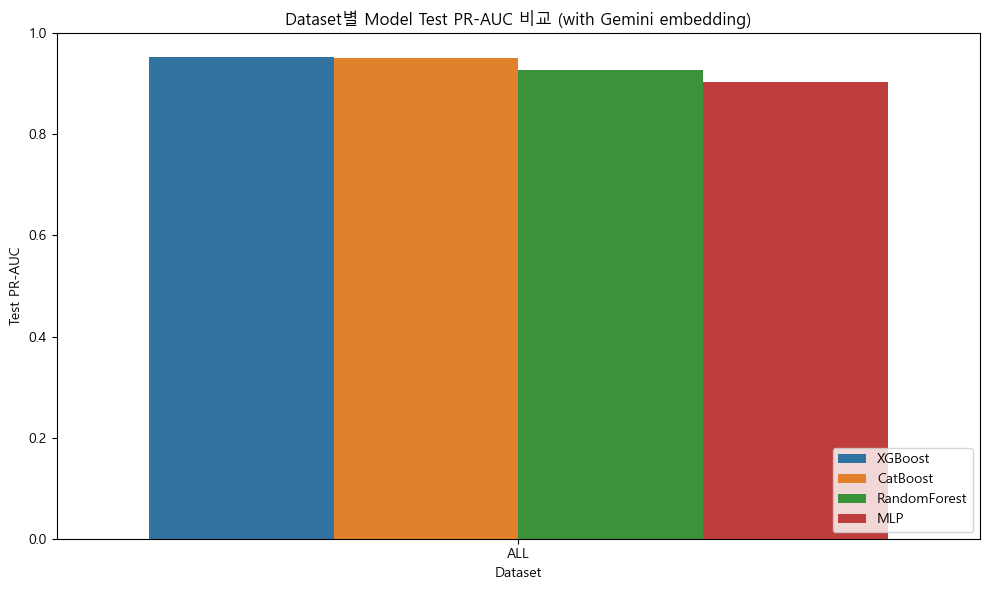

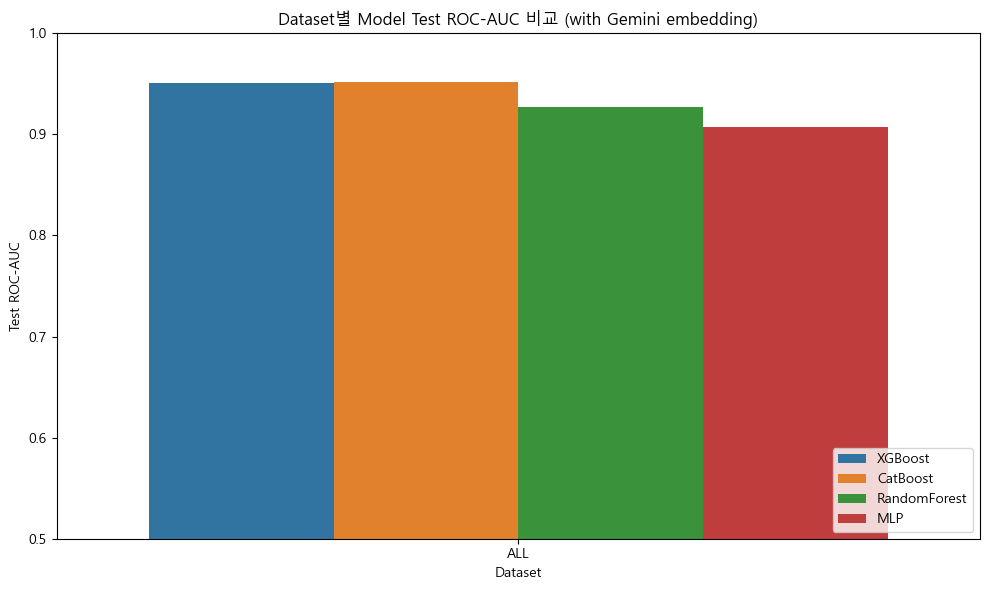

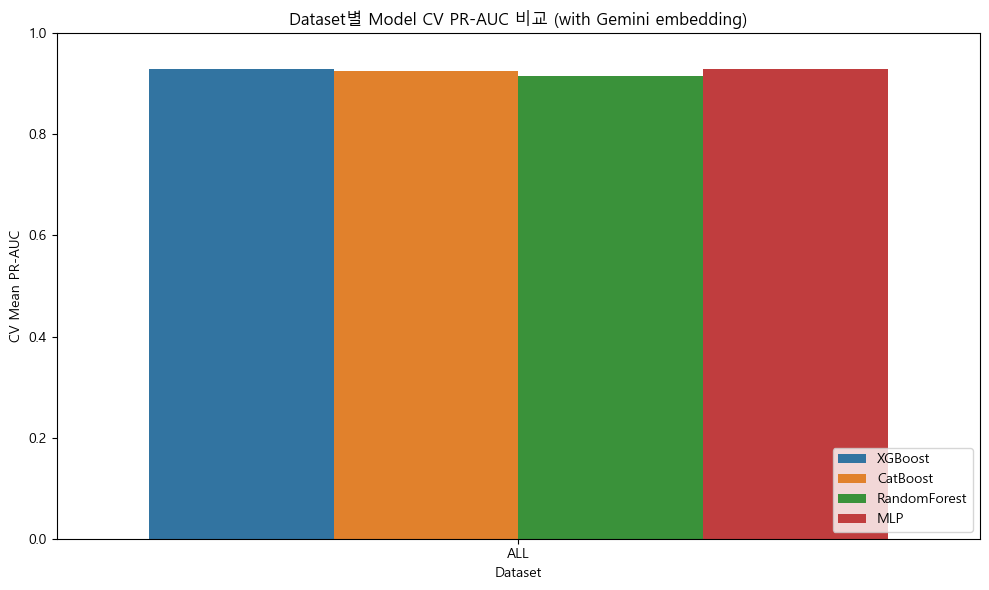

In [16]:
# ============================================================
# 시각화 1: 데이터셋별 모델 PR-AUC / ROC-AUC 비교 막대그래프
# ============================================================

plt.figure(figsize=(10, 6))
sns.barplot(data=result_df, x='dataset', y='test_pr_auc', hue='model')
plt.title('Dataset별 Model Test PR-AUC 비교 (with Gemini embedding)')
plt.ylabel('Test PR-AUC'); plt.xlabel('Dataset'); plt.ylim(0, 1.0)
plt.legend(loc='lower right'); plt.tight_layout(); plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(data=result_df, x='dataset', y='test_roc_auc', hue='model')
plt.title('Dataset별 Model Test ROC-AUC 비교 (with Gemini embedding)')
plt.ylabel('Test ROC-AUC'); plt.xlabel('Dataset'); plt.ylim(0.5, 1.0)
plt.legend(loc='lower right'); plt.tight_layout(); plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(data=result_df, x='dataset', y='cv_pr_auc_mean', hue='model')
plt.title('Dataset별 Model CV PR-AUC 비교 (with Gemini embedding)')
plt.ylabel('CV Mean PR-AUC'); plt.xlabel('Dataset'); plt.ylim(0, 1.0)
plt.legend(loc='lower right'); plt.tight_layout(); plt.show()

In [17]:
def plot_roc_pr_curves(dataset_name: str, trained_models: dict):
    """한 데이터셋에 대해 4개 모델의 ROC / PR 곡선을 한 화면에 겹쳐 그린다."""
    # ROC
    plt.figure(figsize=(8, 6))
    for (d, m_name), obj in trained_models.items():
        if d != dataset_name:
            continue
        y_test, proba = obj['y_test'], obj['proba']
        fpr, tpr, _ = roc_curve(y_test, proba)
        plt.plot(fpr, tpr, label=f'{m_name} (AUC={roc_auc_score(y_test, proba):.3f})')
    plt.plot([0, 1], [0, 1], linestyle='--', label='Random')
    plt.title(f'{dataset_name} ROC Curve (with embedding)')
    plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
    plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

    # PR
    plt.figure(figsize=(8, 6))
    baseline = None
    for (d, m_name), obj in trained_models.items():
        if d != dataset_name:
            continue
        y_test, proba = obj['y_test'], obj['proba']
        precision, recall, _ = precision_recall_curve(y_test, proba)
        plt.plot(recall, precision, label=f'{m_name} (AP={average_precision_score(y_test, proba):.3f})')
        baseline = y_test.mean()
    if baseline is not None:
        # baseline = 양성 비율. PR 곡선이 이보다 위에 있어야 의미가 있음.
        plt.axhline(baseline, linestyle='--', label=f'Baseline={baseline:.3f}')
    plt.title(f'{dataset_name} Precision-Recall Curve (with embedding)')
    plt.xlabel('Recall'); plt.ylabel('Precision')
    plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

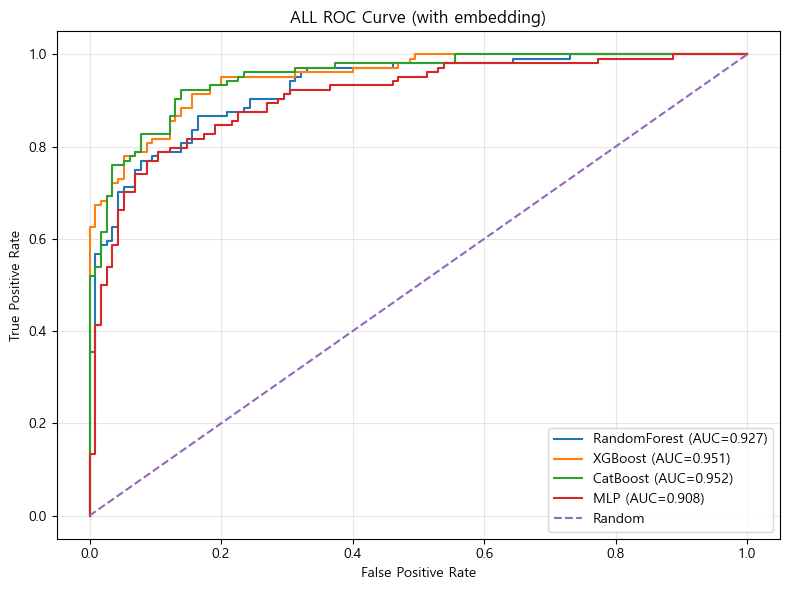

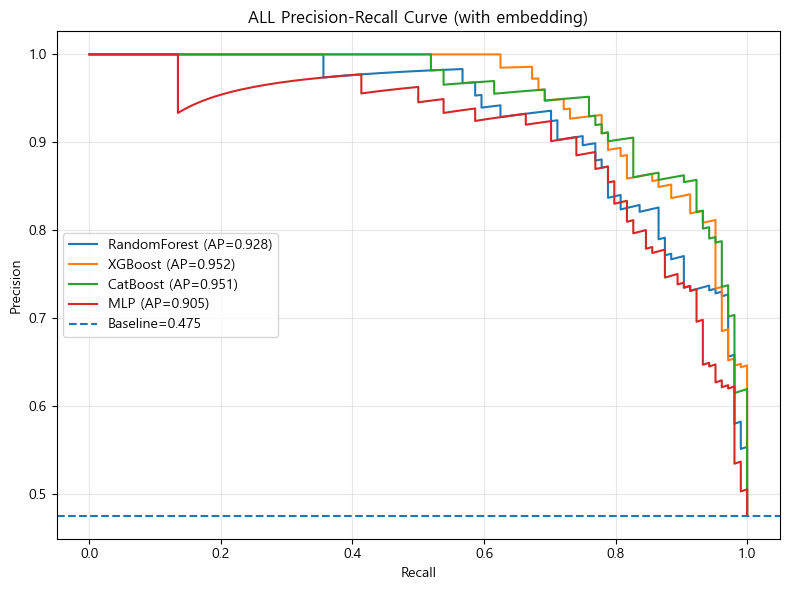

In [18]:
plot_roc_pr_curves('ALL', trained_models)

In [19]:
# ============================================================
# Feature Importance (트리 계열 모델만)
# - 임베딩 768 차원을 개별로 보면 의미가 없으므로 합산해서
#   'embedding(sum)' 한 항목으로 묶어서 표시.
# - 카테고리는 OneHot 후 prefix 가 붙으므로 원본 컬럼명 단위로 다시 묶는다.
# - MLP 처럼 feature_importances_ 를 노출하지 않는 모델은 자동으로 skip.
# ============================================================

def get_feature_importance(dataset_name: str, model_name: str, trained_models: dict) -> pd.DataFrame:
    """모델별 feature importance 를 그룹 단위로 합산해 반환.
    모든 모델이 같은 sklearn Pipeline 에 들어 있어 처리 분기가 단일.
    """
    pipe = trained_models[(dataset_name, model_name)]['model']
    pre = pipe.named_steps['preprocess']
    model = pipe.named_steps['model']
    if not hasattr(model, 'feature_importances_'):
        return pd.DataFrame()  # MLP 등 importance 가 없는 모델은 빈 DataFrame 으로 skip.
    names = list(pre.get_feature_names_out())
    importances = model.feature_importances_

    df_imp = pd.DataFrame({'feature': names, 'importance': importances})
    df_imp['group'] = df_imp['feature'].map(lambda n: group_feature_name(n, structured_feature_cols))
    grouped = df_imp.groupby('group')['importance'].sum().sort_values(ascending=False).reset_index()
    return grouped

In [20]:
# MLP 는 feature_importances_ 가 없어서 importance 분석에서는 빠진다 (자동 skip).
for ds_name in ['ALL']:
    for m_name in ['RandomForest', 'XGBoost', 'CatBoost']:
        imp = get_feature_importance(ds_name, m_name, trained_models)
        if imp.empty:
            continue
        print(f'\n=== {ds_name} / {m_name} (top 15) ===')
        print(imp.head(15).to_string(index=False))


=== ALL / RandomForest (top 15) ===
                   group  importance
          embedding(sum)    0.969790
   cls_marketing_purpose    0.011219
           category_name    0.007462
            cls_cta_type    0.004640
                 caption    0.002122
              tags_count    0.001735
                 영상길이(초)    0.001258
        cls_content_type    0.000528
                  domain    0.000304
       tags_missing_flag    0.000285
           cls_is_series    0.000268
           length_bucket    0.000187
    cls_is_collaboration    0.000156
description_missing_flag    0.000047
              definition    0.000000

=== ALL / XGBoost (top 15) ===
                   group  importance
          embedding(sum)    0.927608
   cls_marketing_purpose    0.032907
           category_name    0.026658
            cls_cta_type    0.005557
                 caption    0.004381
                  domain    0.001177
           cls_is_series    0.000493
                 영상길이(초)    0.000408
    cl

In [21]:
# ============================================================
# SHAP 분석 (ALL 데이터셋만)
# ------------------------------------------------------------
# - Feature importance 는 "어떤 피쳐가 중요한지" 만 알려주는 반면,
#   SHAP 은 각 샘플별로 "어느 방향으로, 얼마나 영향을 줬는지" 까지 보여줌.
# - IT/FnB 까지 다 돌리면 시간이 많이 걸리므로 ALL 한 번만.
# - MLP 는 KernelExplainer 가 783 차원에서 너무 느려서 후보에서 제외.
# - 임베딩 768 개를 개별로 보면 의미가 없어서, bar plot 에서는
#   embedding(sum) 한 그룹으로 묶어서 표시.
# ============================================================

import shap

In [22]:
def pick_best_tree_model_for_shap(result_df: pd.DataFrame, dataset_name: str = 'ALL') -> tuple[str, bool]:
    """ALL 데이터셋에서 test_pr_auc 가 가장 높은 트리 계열 모델을 고른다.

    MLP 가 1등이면 SHAP 후보에서는 제외하고 다음 순위 트리 모델로 fallback.
    동률이면 result_df 정렬 순서대로 첫 번째 모델을 고른다.
    반환값: (model_name, was_fallback)
    """
    sub = result_df[result_df['dataset'] == dataset_name].copy()
    sub = sub.sort_values('test_pr_auc', ascending=False).reset_index(drop=True)

    if sub.empty:
        raise ValueError(f'{dataset_name} 결과가 result_df 에 없습니다.')

    top_overall = sub.iloc[0]['model']

    tree_candidates = sub[sub['model'].isin(['RandomForest', 'XGBoost', 'CatBoost'])]
    if tree_candidates.empty:
        raise ValueError('SHAP 가능한 트리 모델 결과가 없습니다.')

    best_tree = tree_candidates.iloc[0]['model']
    was_fallback = (top_overall != best_tree)
    return best_tree, was_fallback

In [23]:
def get_shap_values_for_tree_model(dataset_name: str, model_name: str, trained_models: dict):
    """트리 모델 한 개에 대해 SHAP 값을 계산.

    반환값:
        X_used: pd.DataFrame (preprocessor 통과 후의 변환 행렬을 DataFrame 으로 감싼 것)
        shap_values_class1: np.ndarray (양성 클래스 기준 SHAP 값)
        feature_names: list[str]
    """
    pipe = trained_models[(dataset_name, model_name)]['model']
    X_test = trained_models[(dataset_name, model_name)]['X_test']
    preprocessor = pipe.named_steps['preprocess']
    model = pipe.named_steps['model']

    X_transformed = preprocessor.transform(X_test)
    if hasattr(X_transformed, 'toarray'):
        X_transformed = X_transformed.toarray()

    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_transformed)

    # binary 분류는 보통 양성 클래스 row 만 필요. SHAP 버전에 따라 list / 3D / 2D 다 나옴.
    if isinstance(shap_values, list):
        shap_values_class1 = shap_values[1]
    elif hasattr(shap_values, 'ndim') and shap_values.ndim == 3:
        shap_values_class1 = shap_values[:, :, 1]
    else:
        shap_values_class1 = shap_values

    feature_names = list(preprocessor.get_feature_names_out())

    # ColumnTransformer 가 붙인 prefix 는 가독성을 떨어뜨려서 떼어낸다.
    feature_names = [strip_ct_prefix(n) for n in feature_names]

    if len(feature_names) != X_transformed.shape[1]:
        print(
            f'[SHAP] feature_names 개수 불일치: names={len(feature_names)}, '
            f'X={X_transformed.shape[1]} -> 임시 이름으로 대체'
        )
        feature_names = [f'feature_{i}' for i in range(X_transformed.shape[1])]

    X_df = pd.DataFrame(X_transformed, columns=feature_names)
    return X_df, shap_values_class1, feature_names

In [24]:
def quantify_shap(X: pd.DataFrame, shap_values_class1: np.ndarray) -> pd.DataFrame:
    """피쳐별 SHAP 통계 테이블. mean_abs_shap 내림차순."""
    return pd.DataFrame({
        'feature': list(X.columns),
        'mean_abs_shap': np.abs(shap_values_class1).mean(axis=0),
        'mean_shap': shap_values_class1.mean(axis=0),
    }).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

In [25]:
def quantify_shap_grouped(
    X: pd.DataFrame,
    shap_values_class1: np.ndarray,
    structured_feature_cols: list[str],
) -> pd.DataFrame:
    """quantify_shap 과 같은 구조이지만 emb_* 를 한 줄로 묶는다.

    OneHot 으로 쪼개진 카테고리는 원본 컬럼명으로 다시 합산.
    """
    base = quantify_shap(X, shap_values_class1)

    base['group'] = base['feature'].map(lambda n: group_feature_name(n, structured_feature_cols))

    # 주의: 그룹의 mean_abs_shap 은 "각 피쳐 mean_abs 의 합" 이지
    # "그룹 합벡터의 mean_abs" 가 아니다. 부호가 상쇄되는 임베딩 그룹에서는
    # 다소 과대 평가될 수 있는 점을 감안해서 본다.
    grouped = base.groupby('group', as_index=False).agg(
        mean_abs_shap=('mean_abs_shap', 'sum'),
        mean_shap=('mean_shap', 'sum'),
    ).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

    return grouped

In [26]:
def plot_shap_bar_grouped(
    X: pd.DataFrame,
    shap_values_class1: np.ndarray,
    structured_feature_cols: list[str],
    top_n: int = 20,
    title: str = '',
):
    """grouped SHAP 결과를 matplotlib 가로 막대로 시각화.

    shap.summary_plot 의 bar 모드는 커스텀 그룹핑을 깔끔하게 못 받아서 직접 그린다.
    """
    grouped = quantify_shap_grouped(
        X, shap_values_class1, structured_feature_cols
    )
    top = grouped.head(top_n).iloc[::-1]  # 가로 막대는 위->아래로 큰 순서가 자연스러움

    plt.figure(figsize=(9, max(4, 0.35 * len(top))))
    plt.barh(top['group'], top['mean_abs_shap'])
    plt.xlabel('mean(|SHAP value|)')
    plt.ylabel('feature (embedding aggregated)')
    plt.title(title or f'SHAP grouped bar (top {top_n})')
    plt.tight_layout()
    plt.show()

In [27]:
def plot_shap_dot_structured_only(
    X: pd.DataFrame,
    shap_values_class1: np.ndarray,
    structured_feature_cols: list[str],
):
    """임베딩을 제외한 구조화 피쳐들만 가지고 dot summary plot.

    구조화 피쳐 ~15 개만 남기면 방향(빨강/파랑) + 영향 분포가 한눈에 보인다.
    카테고리 OneHot 컬럼은 원본 컬럼명으로 시작하므로 그대로 살린다.
    """
    feature_names = list(X.columns)
    struct_set = set(structured_feature_cols)
    keep_idx = []
    keep_names = []
    # 임베딩도 구조형도 아닌 컬럼은 어느 분기에도 안 잡혀서 자동으로 skip 된다.
    for i, name in enumerate(feature_names):
        bare = strip_ct_prefix(name)
        if is_embedding_dim(bare):
            continue
        if bare in struct_set:
            keep_idx.append(i); keep_names.append(bare); continue
        for orig in structured_feature_cols:
            if bare.startswith(orig + '_'):
                keep_idx.append(i); keep_names.append(bare); break

    if not keep_idx:
        print('[SHAP] 구조화 피쳐가 하나도 매칭되지 않음 - dot plot skip')
        return

    shap_struct = shap_values_class1[:, keep_idx]
    X_struct = X.iloc[:, keep_idx]

    shap.summary_plot(
        shap_struct,
        X_struct,
        feature_names=keep_names,
        show=True,
    )

In [28]:
def plot_catboost_waterfall(
    dataset_name: str,
    trained_models: dict,
    sample_idx: int = 0,
    max_display: int = 15,
):
    """CatBoost 한정. 단일 샘플의 SHAP 기여도를 waterfall 로 그린다.

    base_value 는 RawFormulaVal 예측에서 SHAP 값 합을 빼서 역산한다.
    (TreeExplainer 의 expected_value 와 합이 안 맞는 케이스 방어용)
    Pipeline 안에 들어 있으므로 preprocess 로 X 를 변환한 뒤 inner CatBoost 에 직접 호출.
    """
    model_name = 'CatBoost'
    pipe = trained_models[(dataset_name, model_name)]['model']
    inner_cb = pipe.named_steps['model']

    X_used, shap_values_class1, _ = get_shap_values_for_tree_model(
        dataset_name, model_name, trained_models
    )
    # X_used 는 이미 preprocessor 통과한 변환 행렬을 DataFrame 으로 감싼 것이라
    # 그대로 inner_cb.predict 에 넣으면 동일한 입력 스페이스가 된다.

    sv = np.array(shap_values_class1)
    if sv.ndim == 3:
        sv = sv[:, :, 1]

    sample_idx = min(sample_idx, len(X_used) - 1)

    raw_pred = inner_cb.predict(
        X_used.iloc[[sample_idx]].values,
        prediction_type='RawFormulaVal',
    )[0]
    base_value = float(raw_pred - sv[sample_idx].sum())

    explanation = shap.Explanation(
        values=sv[sample_idx],
        base_values=base_value,
        data=X_used.iloc[sample_idx].values,
        feature_names=list(X_used.columns),
    )
    shap.plots.waterfall(explanation, max_display=max_display)

In [29]:
# ============================================================
# 실행: ALL 데이터셋의 best 트리 모델로 SHAP 분석
# ============================================================

_shap_dataset = 'ALL'
_shap_best_model, _shap_was_fallback = pick_best_tree_model_for_shap(result_df, _shap_dataset)

if _shap_was_fallback:
    # MLP 가 1등이었지만 SHAP 후보에서 빼고 다음 트리 모델로 내려간 경우
    print(
        f'[SHAP] {_shap_dataset} 1등 모델은 MLP 였으나 SHAP 후보에서 제외 -> '
        f'fallback to {_shap_best_model}'
    )
else:
    print(f'[SHAP] {_shap_dataset} best tree model: {_shap_best_model}')

[SHAP] ALL best tree model: XGBoost


In [30]:
# SHAP 값 계산 (ALL / best tree). 한 번 계산해서 여러 plot 에 재사용.
X_shap, shap_values_class1, shap_feature_names = get_shap_values_for_tree_model(
    _shap_dataset, _shap_best_model, trained_models
)
print(f'[SHAP] X shape={X_shap.shape}, shap_values shape={np.array(shap_values_class1).shape}')

[SHAP] X shape=(219, 836), shap_values shape=(219, 836)


In [31]:
# 수치 요약 1: 그룹핑 안 한 raw 결과 (top 30)
shap_table = quantify_shap(X_shap, shap_values_class1)
print(f'\n=== SHAP raw (top 30) - {_shap_dataset} / {_shap_best_model} ===')
print(shap_table.head(30).to_string(index=False))


=== SHAP raw (top 30) - ALL / XGBoost ===
                    feature  mean_abs_shap  mean_shap
cls_marketing_purpose_서비스활용       0.279817  -0.055948
                     emb_10       0.265992  -0.022506
                     emb_61       0.200914  -0.046868
                    emb_280       0.196912   0.030710
                    emb_202       0.176430   0.005509
                     emb_45       0.171558  -0.036490
                     emb_25       0.155274   0.033842
                    emb_461       0.148197  -0.025489
                    emb_533       0.139337   0.011463
                    emb_410       0.131659  -0.013041
                    emb_499       0.130841   0.018707
                    emb_589       0.127463   0.019802
                    emb_592       0.124581   0.004621
                    emb_685       0.123618  -0.009298
                    emb_355       0.106607   0.004777
                    emb_596       0.097921  -0.010709
                    emb_420       0.094

In [32]:
# 수치 요약 2: 임베딩을 embedding(sum) 으로 묶은 결과 (top 30)
shap_table_grouped = quantify_shap_grouped(
    X_shap, shap_values_class1, structured_feature_cols
)
print(f'\n=== SHAP grouped (top 30) - {_shap_dataset} / {_shap_best_model} ===')
print(shap_table_grouped.head(30).to_string(index=False))


=== SHAP grouped (top 30) - ALL / XGBoost ===
                     group  mean_abs_shap  mean_shap
            embedding(sum)      11.428118  -0.096950
     cls_marketing_purpose       0.281966  -0.057199
             category_name       0.089861  -0.018438
                   caption       0.052644   0.002242
              cls_cta_type       0.009135  -0.001705
                    domain       0.007444  -0.001286
                   영상길이(초)       0.005395   0.001705
                tags_count       0.003063   0.000670
             cls_is_series       0.002069   0.000153
         tags_missing_flag       0.002034  -0.000178
      cls_is_collaboration       0.001972  -0.000505
          cls_content_type       0.000000   0.000000
                definition       0.000000   0.000000
  description_missing_flag       0.000000   0.000000
                embeddable       0.000000   0.000000
has_paid_product_placement       0.000000   0.000000
             length_bucket       0.000000   0.000000

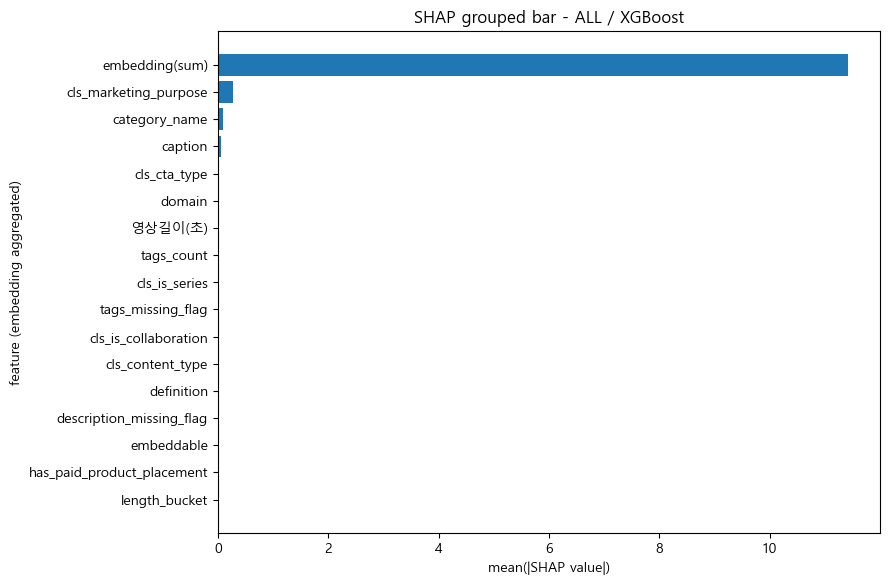

In [33]:
# Plot A: 그룹핑된 SHAP 막대 (embedding 768개를 한 줄로)
plot_shap_bar_grouped(
    X_shap,
    shap_values_class1,
    structured_feature_cols,
    top_n=20,
    title=f'SHAP grouped bar - {_shap_dataset} / {_shap_best_model}',
)

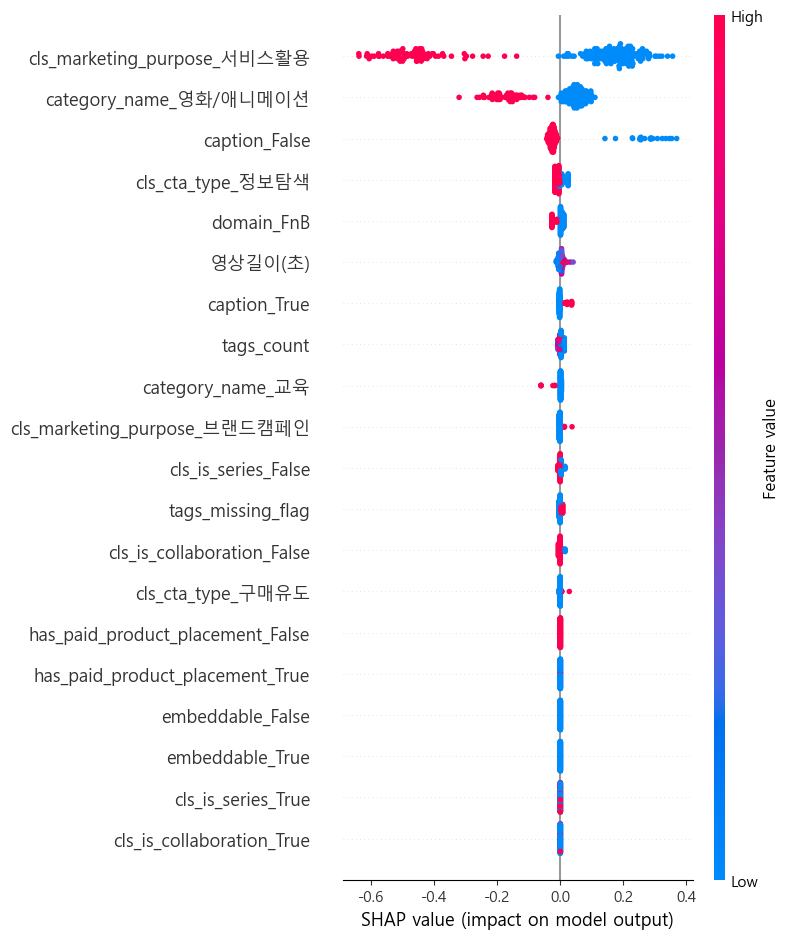

In [34]:
# Plot B: 구조화 피쳐만 dot summary (방향성 + 분포)
plot_shap_dot_structured_only(
    X_shap,
    shap_values_class1,
    structured_feature_cols,
)

In [35]:
# Plot C: CatBoost 가 best 일 때만 waterfall (단일 샘플 해석)
if _shap_best_model == 'CatBoost':
    plot_catboost_waterfall(_shap_dataset, trained_models, sample_idx=0, max_display=15)
else:
    print(f'[SHAP] best 모델이 {_shap_best_model} 라 waterfall skip (CatBoost 전용)')

[SHAP] best 모델이 XGBoost 라 waterfall skip (CatBoost 전용)


In [36]:
# ============================================================
# 모델/메타 저장 (추론 스크립트 predict_longform.py 에서 사용)
# - 모든 모델이 sklearn Pipeline 이라 통일적으로 joblib 단일 포맷.
# - best_models.json: PR-AUC 기준 best 모델명 (데이터셋이 ALL 하나뿐이라 1줄)
# - meta.json: 추론 시 동일 피쳐 셋 재구성용 메타
# 이 셀이 끝나면 models/ 폴더에 4개 모델 + 2개 메타 파일이 생긴다.
# ============================================================
import joblib
import json as _json

MODELS_DIR = PROJECT_ROOT / 'models'
MODELS_DIR.mkdir(parents=True, exist_ok=True)

for (ds_name, m_name), fit_obj in trained_models.items():
    out_path = MODELS_DIR / f'{ds_name}__{m_name}.joblib'
    joblib.dump(fit_obj['model'], out_path)
    print(f'[SAVE] {out_path.name}')

# best 모델 (PR-AUC 기준). 추론 스크립트가 best 를 보고 모델 파일을 결정.
_best_rows = result_df.sort_values('test_pr_auc', ascending=False).groupby('dataset').head(1)
_best_dict = {row['dataset']: row['model'] for _, row in _best_rows.iterrows()}
(MODELS_DIR / 'best_models.json').write_text(
    _json.dumps(_best_dict, indent=2, ensure_ascii=False),
    encoding='utf-8',
)
print(f'[SAVE] best_models.json -> {_best_dict}')

# 메타: 추론 시 입력 1행을 학습과 동일한 피쳐 순서/구성으로 만들 수 있게.
_meta = {
    'gemini_model': GEMINI_EMBEDDING_MODEL,
    'embedding_dim': EMBEDDING_DIM,
    'structured_feature_cols': structured_feature_cols,
    'embedding_feature_cols': embedding_feature_cols,
    'all_feature_cols': all_feature_cols,
    'target': TARGET,
}
(MODELS_DIR / 'meta.json').write_text(
    _json.dumps(_meta, indent=2, ensure_ascii=False),
    encoding='utf-8',
)
print(f'[SAVE] meta.json')

[SAVE] ALL__RandomForest.joblib
[SAVE] ALL__XGBoost.joblib
[SAVE] ALL__CatBoost.joblib
[SAVE] ALL__MLP.joblib
[SAVE] best_models.json -> {'ALL': 'XGBoost'}
[SAVE] meta.json
